In [1]:
#5-1 라이브러리 호출
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms #데이터 전처리를 위해 사용하는 라이브러리
from torch.utils.data import Dataset, DataLoader

In [2]:
#5-2 CPU 혹은 GPU 장치 확인
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

#GPU 사용
# 하나의 GPU를 사용할 땐
#device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#model = Net()
#model.to(device)

#다수의 GPU를 쓰는 경우 
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
#5-3 fashion_mnist 데이터셋 내려받기
train_dataset = torchvision.datasets.FashionMNIST("./data", download=True,
                                                  transform=transforms.Compose([transforms.ToTensor()])) # 훈련 데이터셋을 다운로드

test_dataset = torchvision.datasets.FashionMNIST("./data", download=True,
                                                 train=False, transform=transforms.Compose([transforms.ToTensor()])) #테스트 데이터셋 다운로드

# torchvision.datasets는 torch.utils.data.Dataset의 하위 클래스러 다양한 데이터셋을 포함하고 있음 
# 첫번째 파라미터 (ex. './data') : FashionMNIST를 다운받을 위치를 지겅
# 두번째 파라미터 (ex. 'download=True') : 첫번째 파라미터의 위치에 해당 데이터셋이 있는 지 확인 후 다운로드
# 세번쩨 파라미터 (ex. transform) : 이미지를 텐서(0~1)로 변경

In [4]:
#5-4 fashion_mnist 데이터를 데이터로더에 전달
# 다운로드 받은 fashion_mnist 데이터를 메모리로 불러오기 위해 DataLoader에 전달 
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size= 100)

#1. torch.utils.data.DataLoader()를 사용하여 원하는 크기의 배치 단위로 데이터를 불러오거나 무작위로 섞이도록 할 수 있음 
#1-1. 첫번째 파라미터 (ex. train_dataset) : 데이터를 불러올 데이터셋을 지정
#1-2. 두번째 파라미터 (ex. batch_size=100) : 데이터를 배치로 묶음, 100으로 지정하면 100개 단위로 데이터를 묶음 

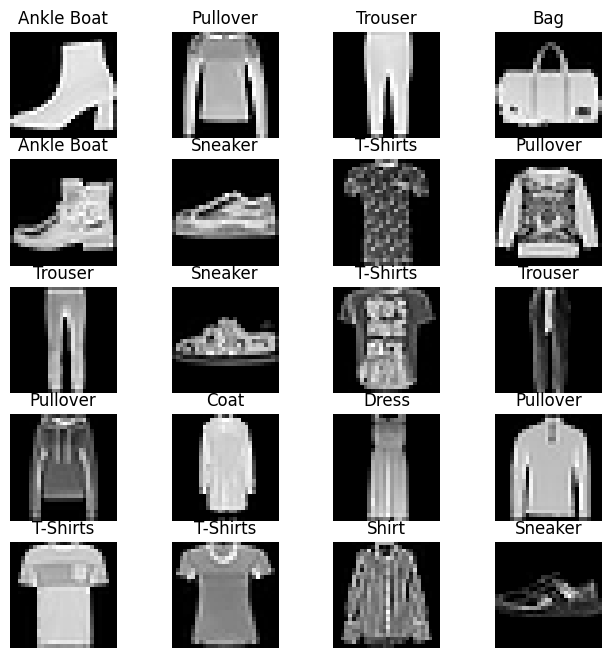

In [5]:
#5-5 분류에 사용될 클래스 정의
labels_map = {0 : 'T-Shirts', 1 : 'Trouser', 2 : 'Pullover', 3 : 'Dress', 4 : 'Coat', 5 : 'Sandal', 6 : 'Shirt',
              7 : 'Sneaker', 8 : 'Bag', 9 : 'Ankle Boat'} #10개의 클래스(분류)

fig = plt.figure(figsize=(8, 8)) #출력할 이미지의 가로세로 길이로 단위는 인치
columns = 4;
rows = 5;

for i in range(1, columns*rows + 1):
    img_xy = np.random.randint(len(train_dataset)); # 1
    img = train_dataset[img_xy][0][0,:,:] # 2
    fig.add_subplot(rows, columns, i)
    plt.title(labels_map[train_dataset[img_xy][1]])
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show() # 20개의 이미지 데이터를 시각적으로 표현

# 1. np.random : 무작위로 데이터를 생성할 때 사용,
# 1-1. np.random.randint() : 이산형 분포를 갖는 데이터에서 무작위 표본을 추출할 때 사용 
# ex1. randint(len(train_dataset))은 0~train_dataset의 길이 만큰의 값을 갖는 분포에서 랜덤한 숫자 하나 추출
# ex2. randint(1, 10) : 1~9의 임의의 숫자를 출력 / randint(10) : 0~10의 임의의 숫자 출력
# ex3. rand(8) : 0~1사이의 정규표준분포 난수를 행렬(1x8) 로 출력
# ex4. rand(4, 2) : 0~1사이의 정규표준분포 난수를 행렬(4x2)로 출력
# ex5. randn(8) : 평균이 0이고, 표준편차가 1인 가우시안 정규분포 난수를 행렬(1x8)로 출력
# ex6. randn(4, 2) : 평균이 0이고, 표준편차가 1인 가우시안 정규분포 난수를 행렬(4x2)로 출력

# 2. train_dataset을 이용한 3차원 배열 생성 
# ex1. examp = np.arange(0, 100, 3) : 1~99의 숫자에서 3씩 건너띈 행렬을 생성
# ex2. examp.resuze(6, 4) : 행렬 크기를 6x4로 조정
# ex3. examp[3] : 3행에 해당하는 모든 요소(값)들을 출력(행과 열은 0부터 시작)
# ex4. examp[3, 3], examp[3],[3] : 3행의 3번째 열에 대한 값(요소) 출력
# ex5. train_dataset[img_xy][0][0,:,:] : 해당 위치에 있는 데이터를 가져오겠다 
# -> MNIST 데이터셋의 경우 데이터셋에서 img_xy번째 샘플을 골라 (이미지, 라벨) 중 이미지만 꺼낸 뒤 그 이미지의 0번 채널(색 층)을 가로·세로 전체

In [6]:
#5-6 심층 신경망 모델 생성
class FashionDNN(nn.Module):  
    def __init__(self): #1
        super(FashionDNN, self).__init__()
        self.fc1 = nn.Linear(in_features=784, out_features=256) #2
        self.drop = nn.Dropout(0.25) #3
        self.fc2 = nn.Linear(in_features=256, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=10)

    def forward(self, input_data): #4
        out = input_data.view(-1, 784) #5
        out = F.relu(self.fc1(out)) #6
        out = self.drop(out)
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        return out

# 1. 클래스 형태의 모델은 항상 torch.nn.Module을 상속
# 1-1. __init__()은 객체가 갖는 속성 값을 초기화하는 역할을 함, 객체가 생성될 때 자동 호출 
# 1-2. super(FashionDNN, self).__init__() : nn.Module 클래스를 상속받겠다는 의미
        
# 2. nn : 딥러니으 모델(네트워크) 구성에 필요한 모듈이 모여져 있는 패키지 
# 2-1. Linear : 단순 선형 회귀 모델을 만들 때 사용 (ex. nn.Linear(in_features=784, out_features=256))
# 2-1 첫번째 파라미터 in_features : 입력의 크기(input size)
# 2-1 두번째 파라미터 out_features : 출력의 크기(output size)
# => 실제로 데이터 연산이 진행되는 forward() 부분에는 첫번째 파라미터만 넘겨주게 되며 해당 forward()에서 연산된 결과가 두번재 파라미터가 정의된 크기가 됨.

# 3. torch.nn.Dropout(p) : p만큼의 비율로 텐서의 값이 0이 됨, 0이 되지 않은 값들은 기존 값에 (1/1-p))만큼 곱해져 커짐 

# 4. forward() : 모델이 학습 데이터를 입력받아서 순전파(forward propagation) 학습을 진행 *반드시 forward라는 이름의 함수여야 함.
# => foward()는 모델이 학습 데이터를 입력 받아서 순전파 연산을 진행하는 함수이며, 객체를 데이터와 함께 호출하면 자동으로 실행 됨  
# => 순전파 연산이란 H(x) 식에 입력 x로 부터 y라는 예측된 값을 얻는 것

# 5. 파이토치에서 사용하는 뷰(view)는 넘파이의 reshape과 같은 역할로 텐서의 크기(shape)를 변경해주는 역할을 함
# 즉, input_data.view(-1, 784) : input_data.view(?, 784)의 크기로 변경하라는 의미 *첫번째 차원(-1)은 사용자가 잘 모르겠으니 파이토치에게 맡기겠다는 의미

# 6. 활성화 함수를 지정할 때 두가지 방법
# 6-1. F.relu() : forward() 함수에서 정의, 함수에서 지정하는 경우 입력과 가중치 자체를 직접 넣어줘야 함
# 6-2. nn.RelU() : __init__() 함수에서 정의, 클래스에서 정의된 경우 옵티마이저가 찾아서 알아서 넣어줌

In [7]:
#5-7 심층 신경망에서 필요한 파라미터 정의 (모델을 학습시키기 전에 손실 함수, 학습률(learning rate), 옵티마이저(optimizer) 정의)ㄴ
learning_rate = 0.001;
model = FashionDNN();
model.to(device)

criterion = nn.CrossEntropyLoss(); #분류 문제에서 사용하는 손실 함수
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate); #1
print(model)

# 1. 옵티마이저를 위한 경사하강법은 Adam을 사용, 학습률을 의미하는 lr은 0.001 사용

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [8]:
#5-8. 심층 신경망을 이용한 모델 학습
num_epochs = 5
count = 0
loss_list = [] #1
iteration_list = []
accuracy_list = []

predictions_list = [] 
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader: #2
        images, laebls = images.to(device), labels.to(device) #3

        train = Variable(images.view(100, 1, 28, 28)) #4
        labels = Variable(labels)

        outputs = model(train) #학습 데이터를 모델에 적용
        loss = criterion(outputs, labels) #예측값과 정답을 넣으면 오차 점수 반환
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count % 50): # count가 50으로 나누었을때 나머지가 0이 아니라면 실행
            total = 0
            correct = 0

            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                test = Variable(images.view(100, 1, 28, 28))
                outputs = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total # 5
            loss_list.append(loss.data) # 1
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500) : 
            print("Interation : {}, Loss : {}, Accuracy : {}%". format(count, loss.data, accuracy))

# 1.배열이나 행렬과 같은 리스트(list) 사용 방법
# loss_list = [] : 비어있는 행렬을 만듬 
# loss_list.append(loss.data) : append() 함수를 사용해서 데이터를 하나씩 추가

# 2. for 구문을 사용하여 레코드(행, 가로줄)를 하나씩 가져옴  
# ex. for x, y in train: 변수 x, y 총 2개를 train(레코드)에서 꺼내서 가져오겠다는 의미
# -> [[10, 20], [30, 40], [50, 60] ...]이 train이고 x, y는 [10, 20], [30, 40], [50, 60] ... 임

# 3. 모델이 데이터를 처리하기 위해서 모델과 데이터가 동일한 장치에 존재해야 함.
# ex. model.to(deive)가 GPU를 사용했다면 images.to(device), labels.to(device)도 GPU에서 처리되어야 함.
# => CPU에서 처리된 데이터를 GPU 모델에 적용되거나 그 반대의 경우 런타임 오류 발생

# 4. Autograd : 자동 미분을 수행하는 파이토치 핵심 패키지, 자동 미분에 대한 값을 저장하기 위해 테이프(tape)를 사용
# -> 순전파(forward) 단계에서 테이프는 수행하는 모든 연산을 저장함 
# -> 역전파(backward) 단계에서 저장된 값(순전파 단계에서)들을 꺼내서 사용
# => Variabled을 사용해서 역전파를 위한 미분 값을 자동으로 계산, 자동 미분을 위해 torch.autograd 패키지 안에 있는 Variable을 이용

# 5. 분류 문제에 대한 정확도는 전체 예측에 대한 정확한 예측의 비율로 표현 가능
# accuracy rate = correct predictions / total predictions * 100
# 5. 오분류율 또는 오류율 
# error rate = (1 - (correct predictions / total predictions)) * 100

Interation : 500, Loss : 0.5812641382217407, Accuracy : 83.23999786376953%
Interation : 1000, Loss : 0.4837687611579895, Accuracy : 84.30000305175781%
Interation : 1500, Loss : 0.3589070439338684, Accuracy : 84.9800033569336%
Interation : 2000, Loss : 0.3800813555717468, Accuracy : 85.2300033569336%
Interation : 2500, Loss : 0.25064948201179504, Accuracy : 85.7699966430664%
Interation : 3000, Loss : 0.32755520939826965, Accuracy : 87.0%


In [9]:
# 5-9. 합성곱 네트워크 생성
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        
        self.layer1 = nn.Sequential( #1
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1), #2
            nn.BatchNorm2d(32), #3
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) #4
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc1 = nn.Linear(in_features=64*6*6, out_features=600) #5
        #self.drop = nn.Dropout2d(0.25)
        self.drop = nn.Dropout(0.25)  
        self.fc2 = nn.Linear(in_features=600, out_features=120)
        self.fc3 = nn.Linear(in_features=120, out_features=10) # 마지막 계층의 out_features는 클래스 개수를 의미

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1) #6
        out = self.fc1(out)
        out = self.drop(out)
        out = self.fc2(out)
        out = self.fc3(out)
        return out


#1. nn.Sequential : __init__()에서 사용할 네트워크 모델들의 정의 + forward() 함수에서 구현될 순전파 계층(layer) 형태로 좀 더 가독성이 뛰어난 코드로 작성
# nn.Sequential은 계층을 차례로 쌓을 수 있도록 Wx + b와 같은 수식과 활성화 함수를 연결해주는 역할  -> 데이터가 각 계층을 순차적으로 지나갈때 사용하면 좋은 방법
# -> nn.Sequential은 여러개의 계층을 하나아 컨테이너에 구현하는 방법

#2. 합성곱층(conv layer) : 합성곱 연산을 통해서 이미지 특징을 추출
# 합성곱 : 커널(or 필터)라는 nxm 크기의 행렬이 높이(height) x 너비(width) 크기의 이미지를 처음부터 끝까지 훑음 -> 각 원소 값끼리 곱한 후 모두 더한 값을 출력
# 커널은 일반적으로 3x3이나 5x5를 사용 
# nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
# in_channels : 입력 채널의 수를 의미, 흑백 이미지 : 1 / RGB 값을 가진 이미지는 3을 가진 경우가 많음
# out_channels : 출력 채널의 수를 의미
# kernel_size : 커널 크기를 의미, 필터라고도 함.
# 커널 : 이미지 특징을 찾아내기 위한 공용 파라미터, CNN에서 학습 대상은 필터의 파라미터가 됨, 입력 데이터를 스트라이드 간격으로 순회하여 합성곱을 계산 
# padding : 패딩의 크기를 의미, 출력 크기를 조정하기 위해 입력 데이터 주위에 0으로 채움 패딩 값이 클수록 출력 크기도 커짐

# 3. BatchNorm2d : 학습 과정에서 각 배치 단위별로 데이터가 다양한 분포를 가지더라도 평균과 분산을 이용하여 정규화하는 것을 의미
# 배치 단위나 계층에 따라 입력 값의 분포가 모두 다르더라도 정규화를 통해 분포를 가우시안 형태로 만듬 -> 평균 0, 표준편차 1로 데이터 분포 조정

# 4. MaxPool2d : 이미지 크기를 축소시키는 용도
# 풀링 계층 : 합성곱층의 출력 데이터를 입력으로 받아서 출력 대이터(activation map)의 크기를 줄이거나 특정 데이터를 강조하는 용도로 사용
# 풀링 계층 처리 방법 : 최대 풀링(max Pooling), 평균 풀링(average Pooling), 최소 풀링(min Pooling)
# nn.MaxPool2d(kernel_size=2, stride=2)
# kerel_size : mxn행렬로 구성된 가중치
# stride : 입력 데이터에 커널(필터)을 적용할 때 이동할 간격, 스트라이드 값이 커지면 출력 크기는 작아짐

# 5. 클래스를 분류하기 위해서 이미지 형태의 데이터를 배열 형태로 변환하여 작업해야함
# conv2d에서 사용하는 하이퍼파라미터 값들에 따라 출력 크기(output suze)가 달라짐
# 패딩과 스트라이드 값에 따라 출력 크기가 달라지며 줄어든 출력 크기는 최종적으로 분류를 담당하는 완전연결층(fully connected layer)으로 전달
# nn.Linear(in_features=64*6*6, out_features=600)
# in_features : 입력 데이터 크기, Conv2d, MaxPool2d는 이미지 데이터를 입력으로 받아 처리함 -> 그 출력 결과를 완전연결층으로 보내기 위해 1차원으로 변경해줘야 함.

# 6. 합성곱층에서 완전연결층으로 변경되기 때문에 데이터의 형태를 1차원을 바꿔줌
# 위의 코드에서 out_size(0)는 100을 의미 -> (100, ?) 크기의 텐서로 변경하겠다는 의미
# out_view(out_size(0), -1)에서 -1은 행(rows)의 수는 정확하게 알고 있으나 열(columns)수는 알지 못한다는 의미
# => 앞에서 batch_size=100 : 데이터를 배치로 묶음, 100으로 지정하면 100개 단위로 데이터를 묶음 -> 즉 100개씩 출력하기 때문
# out.size(0)로 쓰는 이유 : 마지막 묶음이 100장이 안 되거나 평가할 때 배치 크기가 달라져도 자동으로 맞춰줌

In [10]:
# 5-10 합성곱 네트워크를 위한 파라미터 정의
learning_rate = 0.001;
model = FashionCNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [11]:
#5-11 모델 학습 및 성과(합성곱 네트워크)
num_epochs = 5
count = 0
loss_list = [] #1
iteration_list = []
accuracy_list = []

predictions_list = [] 
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader: 
        images, laebls = images.to(device), labels.to(device)

        train = Variable(images.view(100, 1, 28, 28)) 
        labels = Variable(labels)

        outputs = model(train) #학습 데이터를 모델에 적용
        loss = criterion(outputs, labels) #예측값과 정답을 넣으면 오차 점수 반환
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count % 50): # count가 50으로 나누었을때 나머지가 0이 아니라면 실행
            total = 0
            correct = 0

            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                test = Variable(images.view(100, 1, 28, 28))
                outputs = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total 
            loss_list.append(loss.data) 
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500) : 
            print("Interation : {}, Loss : {}, Accuracy : {}%". format(count, loss.data, accuracy))

/opt/anaconda3/envs/torch_book/lib/python3.9/site-packages/torch/nn/functional.py:1535: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


Interation : 500, Loss : 0.5178877711296082, Accuracy : 87.68000030517578%
Interation : 1000, Loss : 0.3088934123516083, Accuracy : 87.91000366210938%
Interation : 1500, Loss : 0.3170768618583679, Accuracy : 88.62000274658203%
Interation : 2000, Loss : 0.25347277522087097, Accuracy : 89.9800033569336%
Interation : 2500, Loss : 0.13087622821331024, Accuracy : 89.02999877929688%
Interation : 3000, Loss : 0.20299161970615387, Accuracy : 90.30000305175781%
